In [1]:
import numpy as np
from netCDF4 import Dataset,num2date,date2num
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy import stats

Compute NAM similar to Gerber et al. 2018

- standardised anomalies of daily 60--90°N geopotential heights at each pressure level
- daily mean and standard deviation are computed over 1 January 1958--31 December 2023 and smoothed with a 30-day running mean
- Thermally-induced trends in geopotential height are accounted for by subtracting the global-mean at each day and pressure level

In [2]:
# ERA5 directory
era_dir = "USER SPECIFY"
# acceleration due to gravity
g=9.80665

In [3]:
years=np.arange(1958,2024,1)

In [4]:
for y, year in enumerate(years):
    print(year)
    nc = Dataset(era_dir+"era5_"+str(year)+"_plevs.nc")
    lats = nc.variables['latitude'][:]
    levs = nc.variables['level'][:]
    
    gph_global_mean = np.average(np.mean(nc.variables['z'][:]/g,axis=-1),axis=-1,weights=np.cos(np.radians(lats)))
    if y==0: 
        gph_pcap = np.average(np.mean(nc.variables['z'][:,:,np.where(lats>=60)[0]]/g,axis=-1),axis=-1,weights=np.cos(np.radians(lats[np.where(lats>=60)[0]]))) - gph_global_mean
        time=num2date(nc.variables['time'][:],calendar=nc.variables['time'].calendar,units=nc.variables['time'].units,only_use_cftime_datetimes=False)
    else: # concatenate with the data loaded in so far
        gph_pcap_new = np.average(np.mean(nc.variables['z'][:,:,np.where(lats>=60)[0]]/g,axis=-1),axis=-1,weights=np.cos(np.radians(lats[np.where(lats>=60)[0]]))) - gph_global_mean
        gph_pcap = np.concatenate((gph_pcap,gph_pcap_new),axis=0)
        time_new = num2date(nc.variables['time'][:],calendar=nc.variables['time'].calendar,units=nc.variables['time'].units,only_use_cftime_datetimes=False)
        time=np.concatenate((time,time_new))
    nc.close()

1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [5]:
# convert time to day of year
doy_arr = np.array([int(datetime.strftime(t,'%j')) for t in time])

In [6]:
# create climatology
climo_mean = np.full((366,len(levs)),np.nan)
climo_std = np.full((366,len(levs)),np.nan)

for d, doy in enumerate(np.arange(1,367,1)):
    if doy<366:
        idxs = np.where(doy_arr==doy)[0]
    if doy==366: # use day 365 and 366
        idxs=np.where(doy_arr>=365)[0]
    climo_mean[d]=np.mean(gph_pcap[idxs],axis=0)
    climo_std[d]=np.std(gph_pcap[idxs],axis=0)

In [7]:
# smooth the climo
climo_smooth_days=30
climo_mean_smooth = uniform_filter1d(climo_mean,size=climo_smooth_days,axis=0,mode='wrap')
climo_std_smooth = uniform_filter1d(climo_std,size=climo_smooth_days,axis=0,mode='wrap')

In [8]:
# clear memory
del climo_mean
del climo_std

In [9]:
# anomalies
nam=np.full(np.shape(gph_pcap),np.nan)
for d, doy in enumerate(doy_arr):
    nam[d]=-1*(gph_pcap[d]-climo_mean_smooth[doy-1])/climo_std_smooth[doy-1]

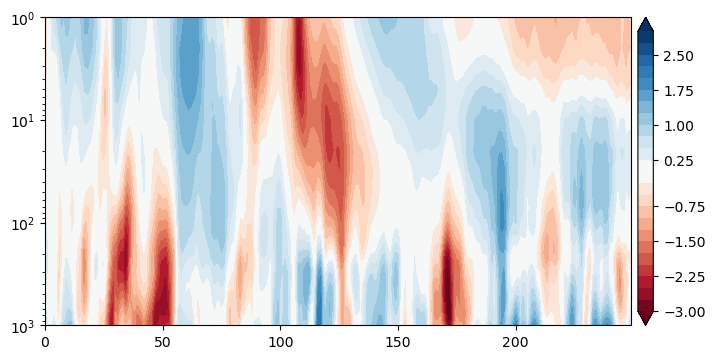

In [10]:
# test plot
clevs=np.concatenate((np.arange(-3,0,0.25),np.arange(0.25,3.25,0.25)))

tidx = np.where(time==datetime(2022,11,1))[0][0]
plt.figure(figsize=(9,4))
im=plt.contourf(np.arange(250),levs,nam[tidx:tidx+250].T,cmap='RdBu',levels=clevs,extend='both')
cn = plt.colorbar(im,spacing='proportional',pad=0.01)
plt.semilogy()
plt.gca().invert_yaxis()